In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/train.csv")

df.head

<bound method NDFrame.head of               date  store  item  sales
0       2013-01-01      1     1     13
1       2013-01-02      1     1     11
2       2013-01-03      1     1     14
3       2013-01-04      1     1     13
4       2013-01-05      1     1     10
...            ...    ...   ...    ...
912995  2017-12-27     10    50     63
912996  2017-12-28     10    50     59
912997  2017-12-29     10    50     74
912998  2017-12-30     10    50     62
912999  2017-12-31     10    50     82

[913000 rows x 4 columns]>

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (913000, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [4]:
df.isnull().sum()
df.describe(include="all")

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
unique,1826,NaN,NaN,NaN
top,2013-01-01,NaN,NaN,NaN
freq,500,NaN,NaN,NaN
mean,NaN,5.500000,25.500000,52.250287
std,NaN,2.872283,14.430878,28.801144
min,NaN,1.000000,1.000000,0.000000
25%,NaN,3.000000,13.000000,30.000000
50%,NaN,5.500000,25.500000,47.000000
75%,NaN,8.000000,38.000000,70.000000


In [5]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicate Rows: 0


In [6]:
df.columns.tolist()

['date', 'store', 'item', 'sales']

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns

numeric_cols

Index(['store', 'item', 'sales'], dtype='object')

In [8]:
categorical_cols = df.select_dtypes(exclude=np.number).columns
categorical_cols

Index(['date'], dtype='object')

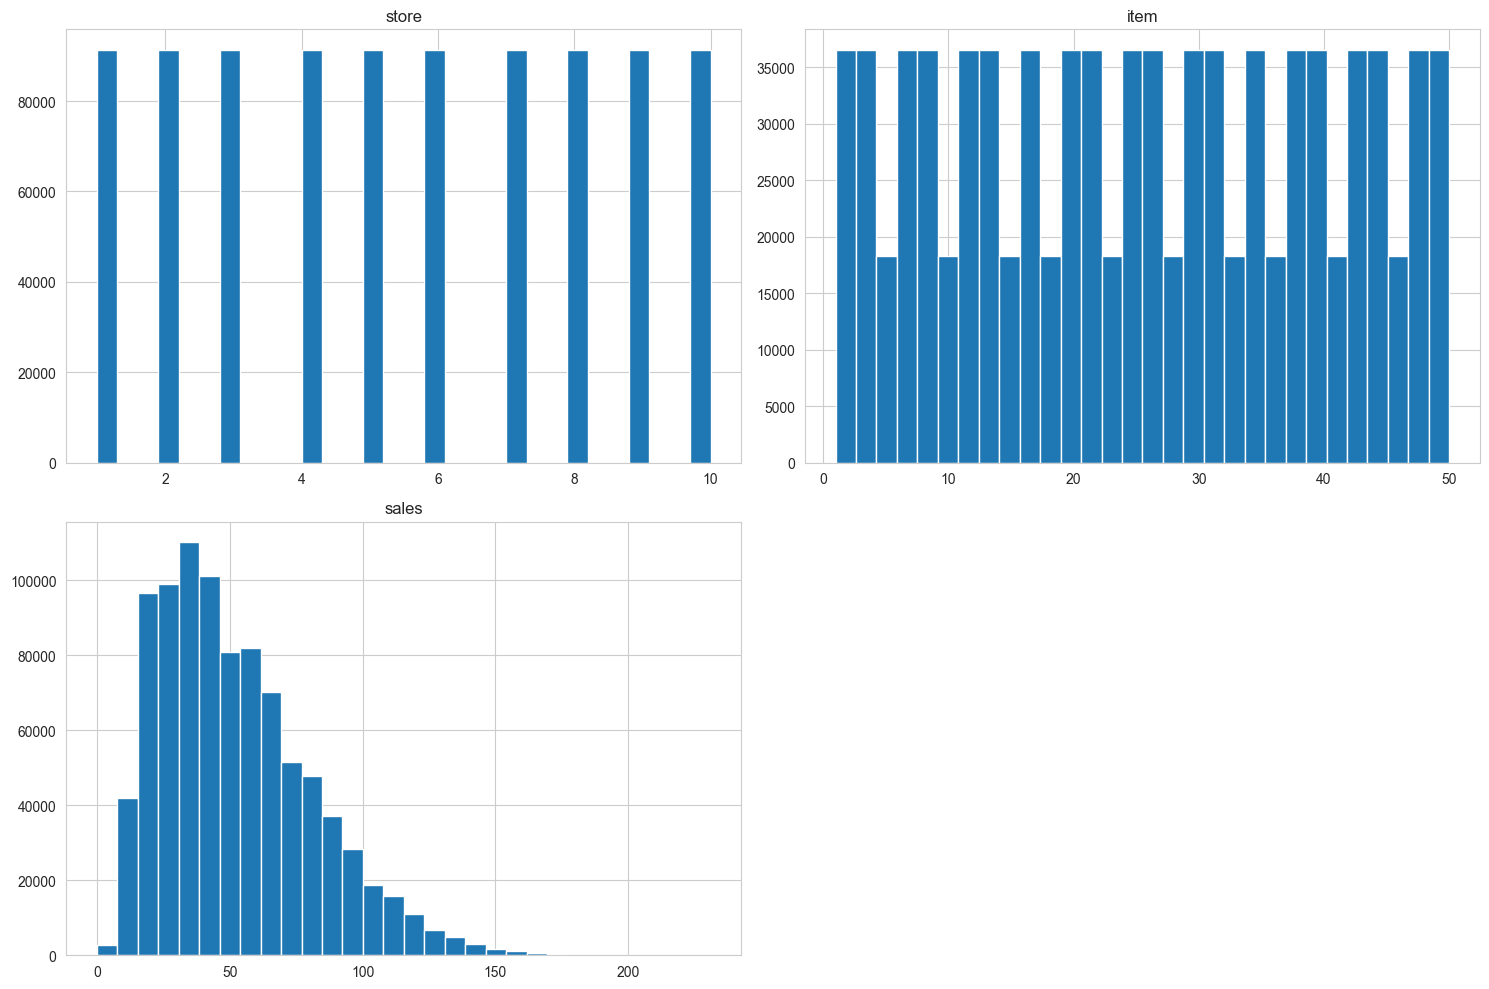

In [9]:
df[numeric_cols].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

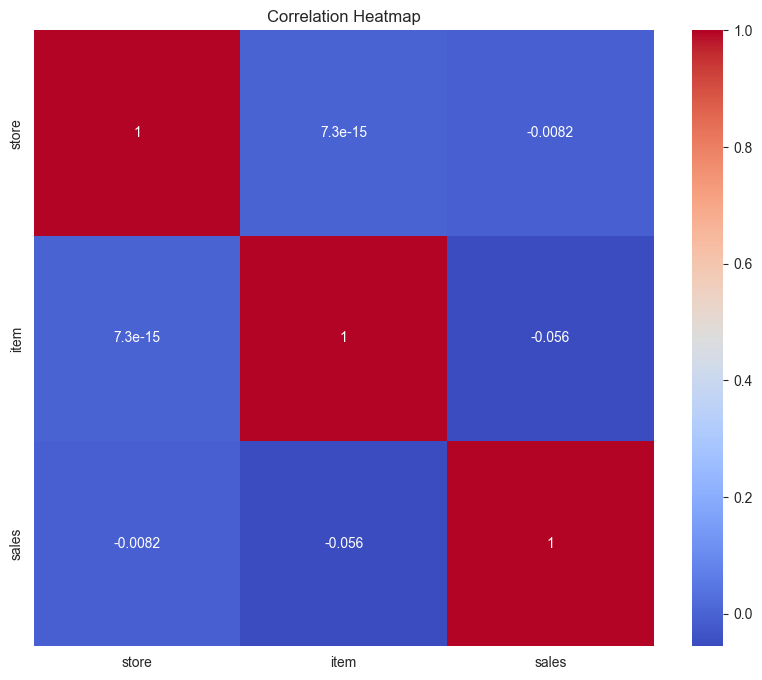

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

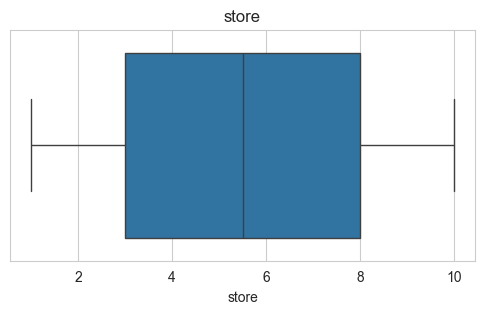

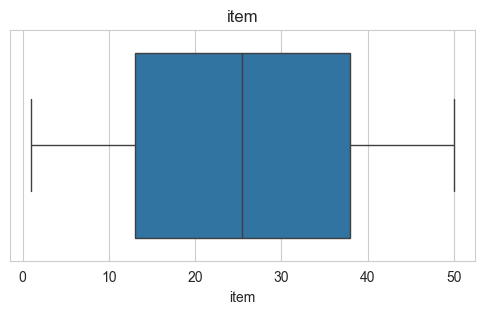

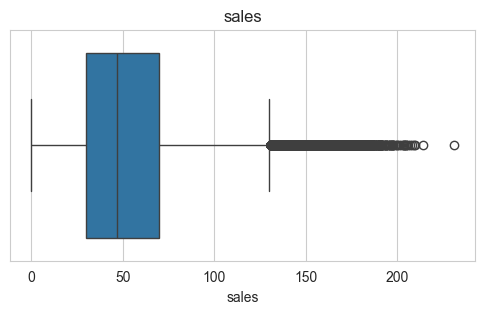

In [11]:
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [12]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


date
date
2013-01-01    500
2013-01-02    500
2013-01-03    500
2013-01-04    500
2013-01-05    500
             ... 
2017-12-27    500
2017-12-28    500
2017-12-29    500
2017-12-30    500
2017-12-31    500
Name: count, Length: 1826, dtype: int64


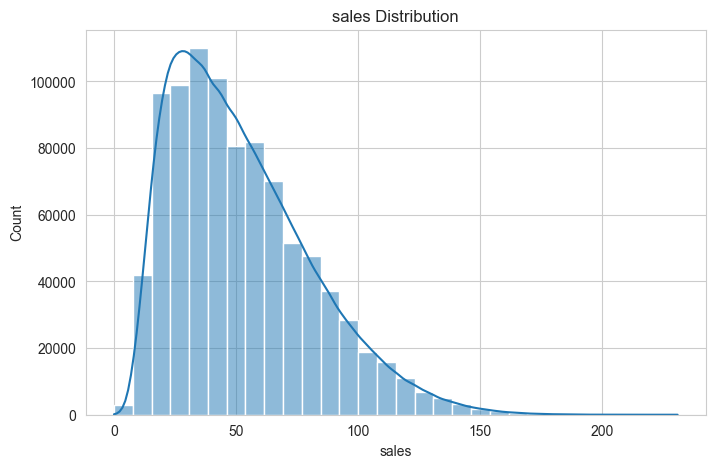

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["sales"], bins=30, kde=True)

plt.title("sales Distribution")
plt.show()

In [14]:
df.to_csv("../data/train.csv", index=False)